In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Convert data to dataframe
df = pd.read_csv('codon_usage.csv', low_memory=False)

In [4]:
# check columns of dataframe
df.columns

Index(['Kingdom', 'DNAtype', 'SpeciesID', 'Ncodons', 'SpeciesName', 'UUU',
       'UUC', 'UUA', 'UUG', 'CUU', 'CUC', 'CUA', 'CUG', 'AUU', 'AUC', 'AUA',
       'AUG', 'GUU', 'GUC', 'GUA', 'GUG', 'GCU', 'GCC', 'GCA', 'GCG', 'CCU',
       'CCC', 'CCA', 'CCG', 'UGG', 'GGU', 'GGC', 'GGA', 'GGG', 'UCU', 'UCC',
       'UCA', 'UCG', 'AGU', 'AGC', 'ACU', 'ACC', 'ACA', 'ACG', 'UAU', 'UAC',
       'CAA', 'CAG', 'AAU', 'AAC', 'UGU', 'UGC', 'CAU', 'CAC', 'AAA', 'AAG',
       'CGU', 'CGC', 'CGA', 'CGG', 'AGA', 'AGG', 'GAU', 'GAC', 'GAA', 'GAG',
       'UAA', 'UAG', 'UGA'],
      dtype='str')

In [5]:
#  I will do my analysis on 
kingdoms = list(df.loc[:, 'Kingdom'].unique())
kingdoms

['vrl', 'arc', 'bct', 'phg', 'plm', 'pln', 'inv', 'vrt', 'mam', 'rod', 'pri']

In [6]:
# Remove columns not useful for analysis  
col_to_remove = ['DNAtype', 'SpeciesID', 'Ncodons', 'SpeciesName']
df_clipped = df.loc[:, ~df.columns.isin(col_to_remove)]
df_clipped.columns

Index(['Kingdom', 'UUU', 'UUC', 'UUA', 'UUG', 'CUU', 'CUC', 'CUA', 'CUG',
       'AUU', 'AUC', 'AUA', 'AUG', 'GUU', 'GUC', 'GUA', 'GUG', 'GCU', 'GCC',
       'GCA', 'GCG', 'CCU', 'CCC', 'CCA', 'CCG', 'UGG', 'GGU', 'GGC', 'GGA',
       'GGG', 'UCU', 'UCC', 'UCA', 'UCG', 'AGU', 'AGC', 'ACU', 'ACC', 'ACA',
       'ACG', 'UAU', 'UAC', 'CAA', 'CAG', 'AAU', 'AAC', 'UGU', 'UGC', 'CAU',
       'CAC', 'AAA', 'AAG', 'CGU', 'CGC', 'CGA', 'CGG', 'AGA', 'AGG', 'GAU',
       'GAC', 'GAA', 'GAG', 'UAA', 'UAG', 'UGA'],
      dtype='str')

In [10]:
# View datatypes of columns
# Find columns that aren't floats
df_dtypes = df_clipped.dtypes.reset_index()
float_mask = df_dtypes.loc[:, 0] != 'float64'
df_dtypes.loc[float_mask]

,index,0
0,Kingdom,str
1,UUU,str
2,UUC,str


As you can see all but three columns are floats. However, only the kingdom column should be a string we have to convert the other two columns to floats in order to perform this analysis. 

In [ ]:
# Convert these columns to floats by dealing with the values that can't be converted
cols = ["UUU", "UUC"]

# coerce invalid to NaN
df_clipped[cols] = df_clipped[cols].apply(pd.to_numeric, errors="coerce")

# drop rows failing either column
df_clean = df_clipped.dropna(subset=cols).copy()

# enforce float
df_clean[cols] = df_clean[cols].astype("float64")

df_clean.dtypes

Kingdom        str
UUU        float64
UUC        float64
UUA        float64
UUG        float64
            ...   
GAA        float64
GAG        float64
UAA        float64
UAG        float64
UGA        float64
Length: 65, dtype: object

In [ ]:
# Is there any na values?
df_clean.isna().sum().sum() # No

np.int64(0)

In [30]:
# Group by kingdom
df_kings = df_clean.groupby('Kingdom').mean()

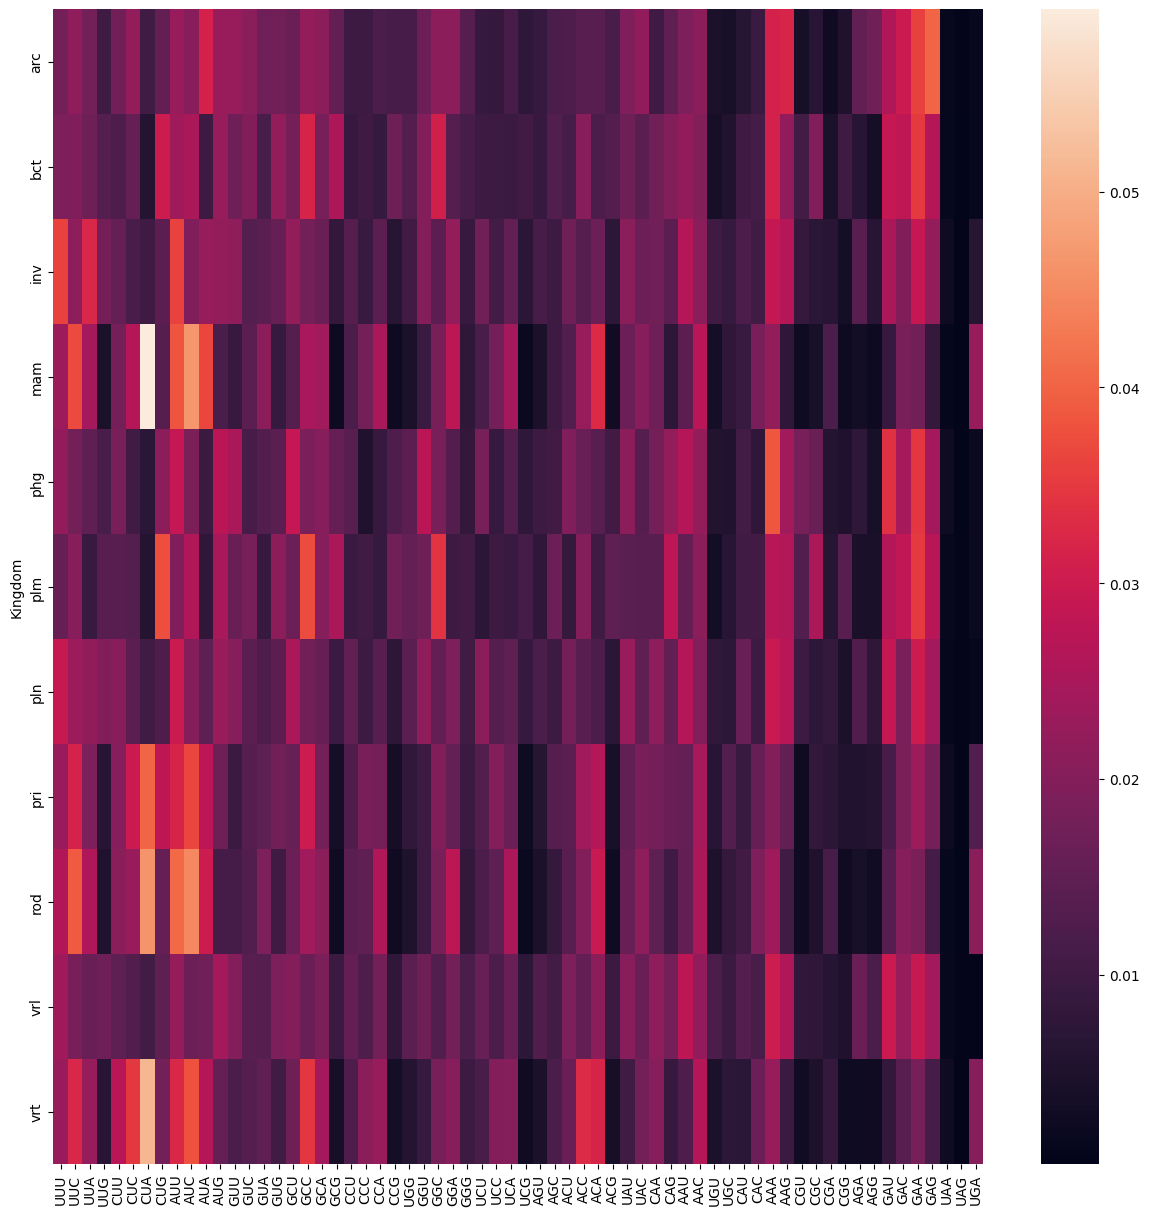

In [37]:
plt.figure(figsize=(15, 15))
sns.heatmap(df_kings)

plt.show()